# 📊 The Central Limit Theorem: Why Averages Follow a Bell Curve

## A Comprehensive Guide to One of Statistics' Most Powerful Ideas

---

## 1. Introduction

The **Central Limit Theorem (CLT)** is arguably the most important concept in statistics. It answers a fundamental question:

> *If I take repeated samples from a population and calculate their means, what pattern will those means follow?*

The answer is stunning: **No matter what the original population looks like, the distribution of sample means approaches a normal (bell curve) distribution.**

This single idea underpins:
- Confidence intervals
- Hypothesis testing
- A/B testing in tech
- Quality control in manufacturing
- Polling and surveys
- Risk modeling in finance

Without the CLT, modern statistics would collapse. Let's explore why.

## 2. Formal Definition

### The Central Limit Theorem States:

If we:
1. Draw independent random samples of size $n$ from a population with mean $\mu$ and standard deviation $\sigma$
2. Calculate the mean $\bar{X}$ for each sample
3. Collect all these sample means

Then, as $n$ gets larger, the distribution of these sample means will:

- **Approach a normal distribution** (bell curve), *regardless of the shape of the original population*
- Have a **mean equal to the population mean**: $E[\bar{X}] = \mu$
- Have a **standard deviation** (called the standard error): $SE = \frac{\sigma}{\sqrt{n}}$

### Mathematical Notation:

$$\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)$$

As $n \to \infty$, the distribution of $\bar{X}$ becomes increasingly normal, even if the original population is skewed, bimodal, uniform, or any other distribution.

### Why This Matters:

- We can make statistical inferences about a population using only a *sample*
- We can calculate confidence intervals and perform hypothesis tests
- We don't need to know the population distribution—the sample means will still be normal
- Larger samples converge faster to normality (smaller standard error = more precise estimates)

## 3. Intuitive Explanation

### Why Does This Happen?

Imagine a population of heights. Some are very tall, some very short, some average.

**If you pick just one person, their height is random**—could be anywhere in that distribution.

**But if you pick 100 people and average their heights, something magical happens:**

- The extremes (very tall, very short) are balanced out
- The average of 100 people is unlikely to be extreme
- If you repeat this 1,000 times, those 1,000 averages cluster around the true population mean
- The clustering itself follows a bell curve

**Why?** Because averaging is a "smoothing" operation. Random fluctuations from the extremes cancel each other out.

### A Simple Analogy:

Imagine flipping a single coin. It's either heads (1) or tails (0)—two discrete outcomes, no bell curve.

But flip 1,000 coins and calculate the proportion of heads. Do this 10,000 times. The histogram of those proportions? **It looks like a bell curve.**

The more coins you flip per trial, the tighter the bell curve (the standard error shrinks).

### Key Insight:

**Averaging reduces randomness.** The more data points you average, the less variability in your estimate. This is why larger sample sizes give more reliable results—the standard error is inversely proportional to $\sqrt{n}$.

## 4. Setup & Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, uniform, expon, chi2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'

## 5. Simulation: The Central Limit Theorem in Action

### 5.1 Simulation 1: Uniform Distribution → Normal Distribution of Means

Population mean: 4.9949
Population std:  2.8834

n=  1 | mean=5.0043 | std=2.8777 | theoretical SE=2.8834
n=  2 | mean=5.0700 | std=2.0388 | theoretical SE=2.0389
n=  5 | mean=5.0112 | std=1.2860 | theoretical SE=1.2895
n= 30 | mean=5.0006 | std=0.5240 | theoretical SE=0.5264
n=100 | mean=4.9936 | std=0.2917 | theoretical SE=0.2883


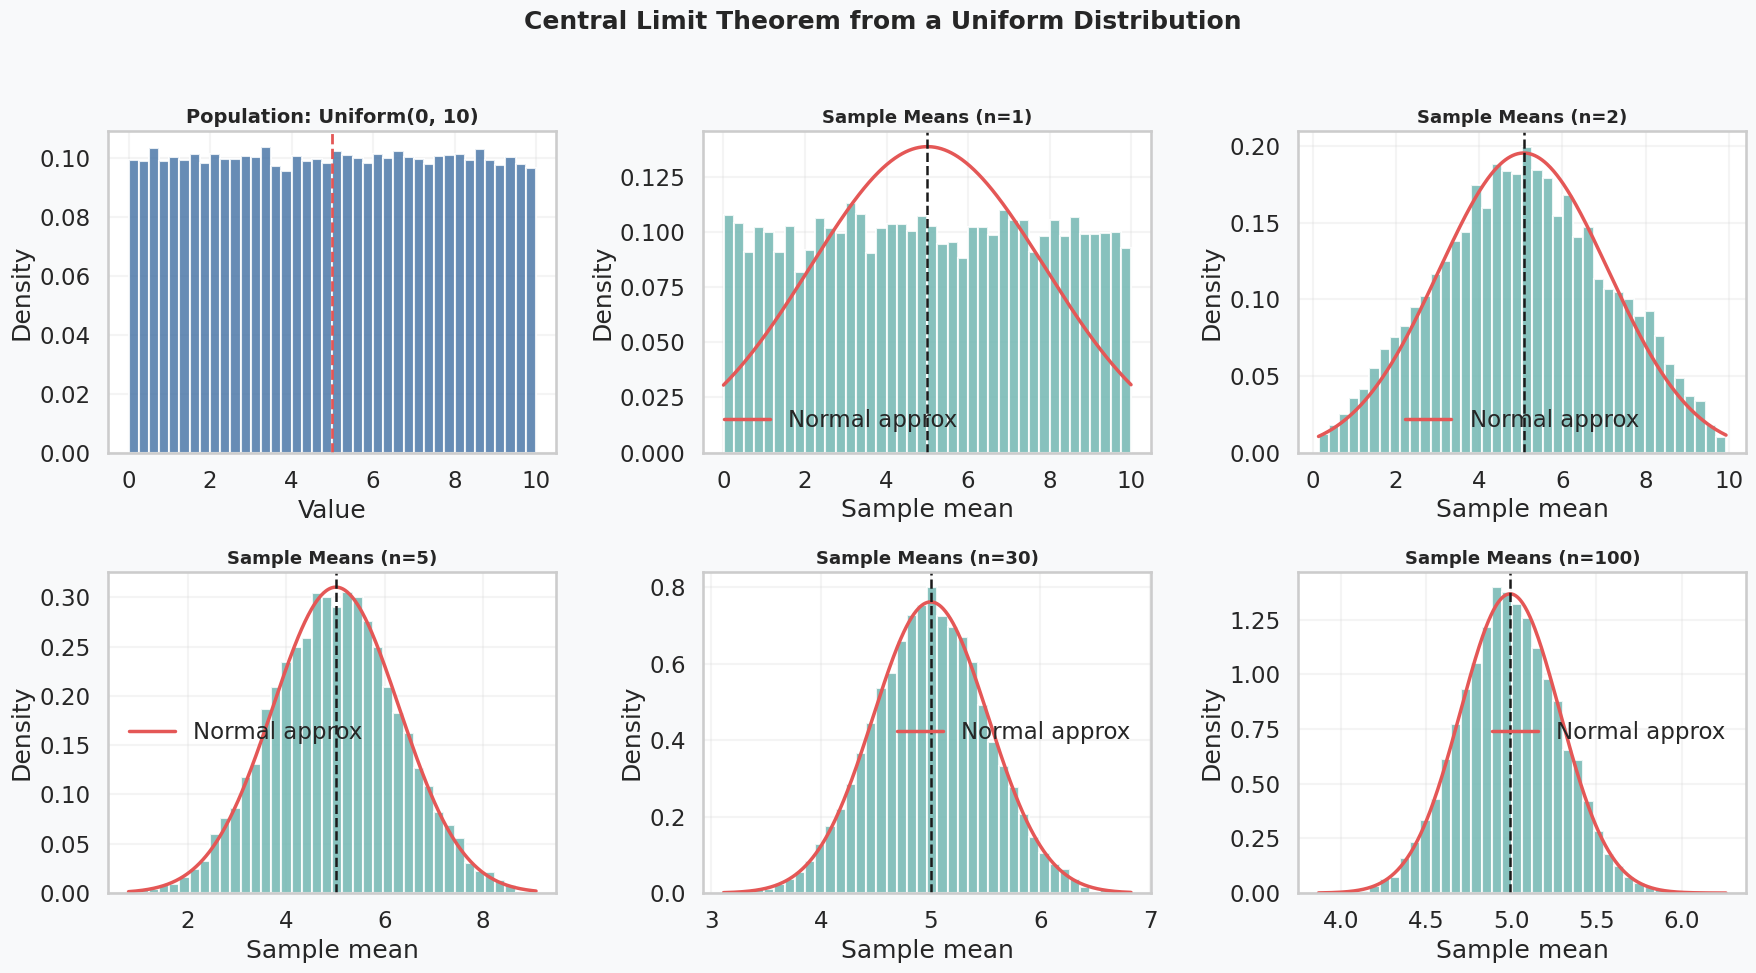

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

population_size = 100000
num_trials = 10000
sample_sizes = [1, 2, 5, 30, 100]

# Uniform population
population = np.random.uniform(0, 10, population_size)
population_mean = np.mean(population)
population_std = np.std(population)

print(f"Population mean: {population_mean:.4f}")
print(f"Population std:  {population_std:.4f}")
print()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot population
axes[0].hist(
    population,
    bins=40,
    density=True,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="white"
)
axes[0].axvline(population_mean, color="#E45756", linestyle="--", linewidth=2)
axes[0].set_title("Population: Uniform(0, 10)", fontsize=14, weight="bold")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.2)

# Plot sample means for different n
for i, n in enumerate(sample_sizes, start=1):
    sample_means = np.mean(
        np.random.choice(population, size=(num_trials, n)),
        axis=1
    )

    sample_mean_mean = np.mean(sample_means)
    sample_mean_std = np.std(sample_means)
    theoretical_se = population_std / np.sqrt(n)

    print(f"n={n:>3} | mean={sample_mean_mean:.4f} | "
          f"std={sample_mean_std:.4f} | theoretical SE={theoretical_se:.4f}")

    ax = axes[i]
    ax.hist(
        sample_means,
        bins=40,
        density=True,
        color="#72B7B2",
        alpha=0.85,
        edgecolor="white"
    )

    # Normal overlay
    x = np.linspace(sample_means.min(), sample_means.max(), 500)
    y = (1 / (sample_mean_std * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - sample_mean_mean) / sample_mean_std) ** 2
    )
    ax.plot(x, y, color="#E45756", linewidth=2.5, label="Normal approx")
    ax.axvline(sample_mean_mean, color="#1A1A1A", linestyle="--", linewidth=1.8)

    ax.set_title(f"Sample Means (n={n})", fontsize=13, weight="bold")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

plt.suptitle("Central Limit Theorem from a Uniform Distribution", fontsize=18, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 5.2 Simulation 2: Exponential Distribution → Normal Distribution of Means

Exponential Population Statistics:
  Mean: 1.9919
  Std Dev: 1.9859
  Shape: Exponential (heavily skewed right)

n=  1 | mean=1.9878 | std=1.9552 | theoretical SE=1.9859
n=  2 | mean=2.0355 | std=1.4299 | theoretical SE=1.4043
n=  5 | mean=2.0062 | std=0.8942 | theoretical SE=0.8881
n= 10 | mean=1.9987 | std=0.6251 | theoretical SE=0.6280
n= 30 | mean=1.9903 | std=0.3609 | theoretical SE=0.3626
n=100 | mean=1.9933 | std=0.2024 | theoretical SE=0.1986


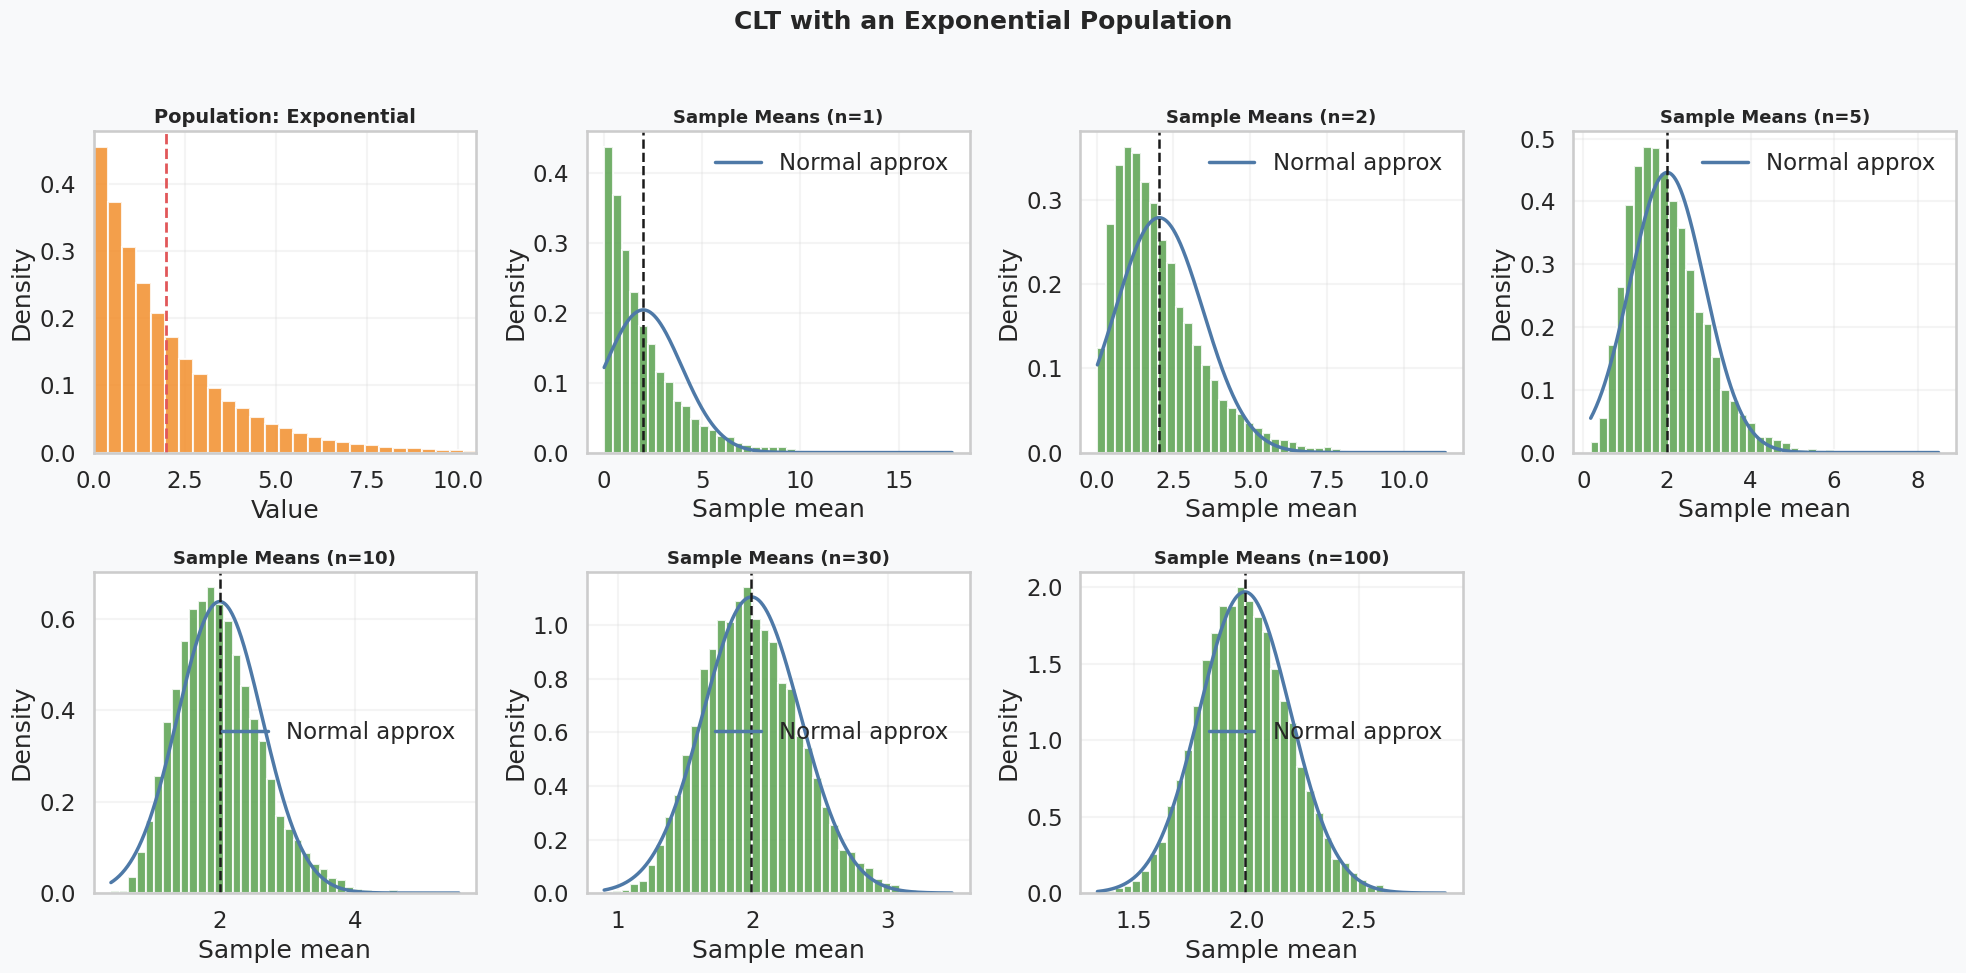

In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

population_size = 100000
num_trials = 10000
sample_sizes = [1, 2, 5, 10, 30, 100]

# Exponential population
population_exp = np.random.exponential(scale=2.0, size=population_size)
population_exp_mean = np.mean(population_exp)
population_exp_std = np.std(population_exp)

print("Exponential Population Statistics:")
print(f"  Mean: {population_exp_mean:.4f}")
print(f"  Std Dev: {population_exp_std:.4f}")
print(f"  Shape: Exponential (heavily skewed right)")
print()

# 2x4 gives 8 slots, enough for 7 plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Population plot
axes[0].hist(
    population_exp,
    bins=60,
    density=True,
    color="#F28E2B",
    alpha=0.85,
    edgecolor="white"
)
axes[0].axvline(population_exp_mean, color="#E15759", linestyle="--", linewidth=2)
axes[0].set_title("Population: Exponential", fontsize=14, weight="bold")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, np.percentile(population_exp, 99.5))
axes[0].grid(alpha=0.2)

# Sample means plots
for i, n in enumerate(sample_sizes, start=1):
    sample_means_exp = np.mean(
        np.random.choice(population_exp, size=(num_trials, n)),
        axis=1
    )

    mean_means = np.mean(sample_means_exp)
    std_means = np.std(sample_means_exp)
    theoretical_se = population_exp_std / np.sqrt(n)

    print(f"n={n:>3} | mean={mean_means:.4f} | "
          f"std={std_means:.4f} | theoretical SE={theoretical_se:.4f}")

    ax = axes[i]
    ax.hist(
        sample_means_exp,
        bins=40,
        density=True,
        color="#59A14F",
        alpha=0.85,
        edgecolor="white"
    )

    x = np.linspace(sample_means_exp.min(), sample_means_exp.max(), 500)
    y = (1 / (std_means * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mean_means) / std_means) ** 2
    )
    ax.plot(x, y, color="#4E79A7", linewidth=2.5, label="Normal approx")
    ax.axvline(mean_means, color="#1A1A1A", linestyle="--", linewidth=1.8)

    ax.set_title(f"Sample Means (n={n})", fontsize=13, weight="bold")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

# Hide unused subplot(s)
for j in range(len(sample_sizes) + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("CLT with an Exponential Population", fontsize=18, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 5.3 Simulation 3: Effect of Sample Size on Convergence

Effect of Sample Size on Standard Error:

Sample Size | Std Dev of Means | Theoretical SE | Convergence
-----------------------------------------------------------------
      5     |      0.8940        |     0.8881     |  0.66%
     15     |      0.5103        |     0.5128     |  0.48%
     30     |      0.3592        |     0.3626     |  0.93%
     50     |      0.2810        |     0.2809     |  0.06%
    100     |      0.1984        |     0.1986     |  0.12%


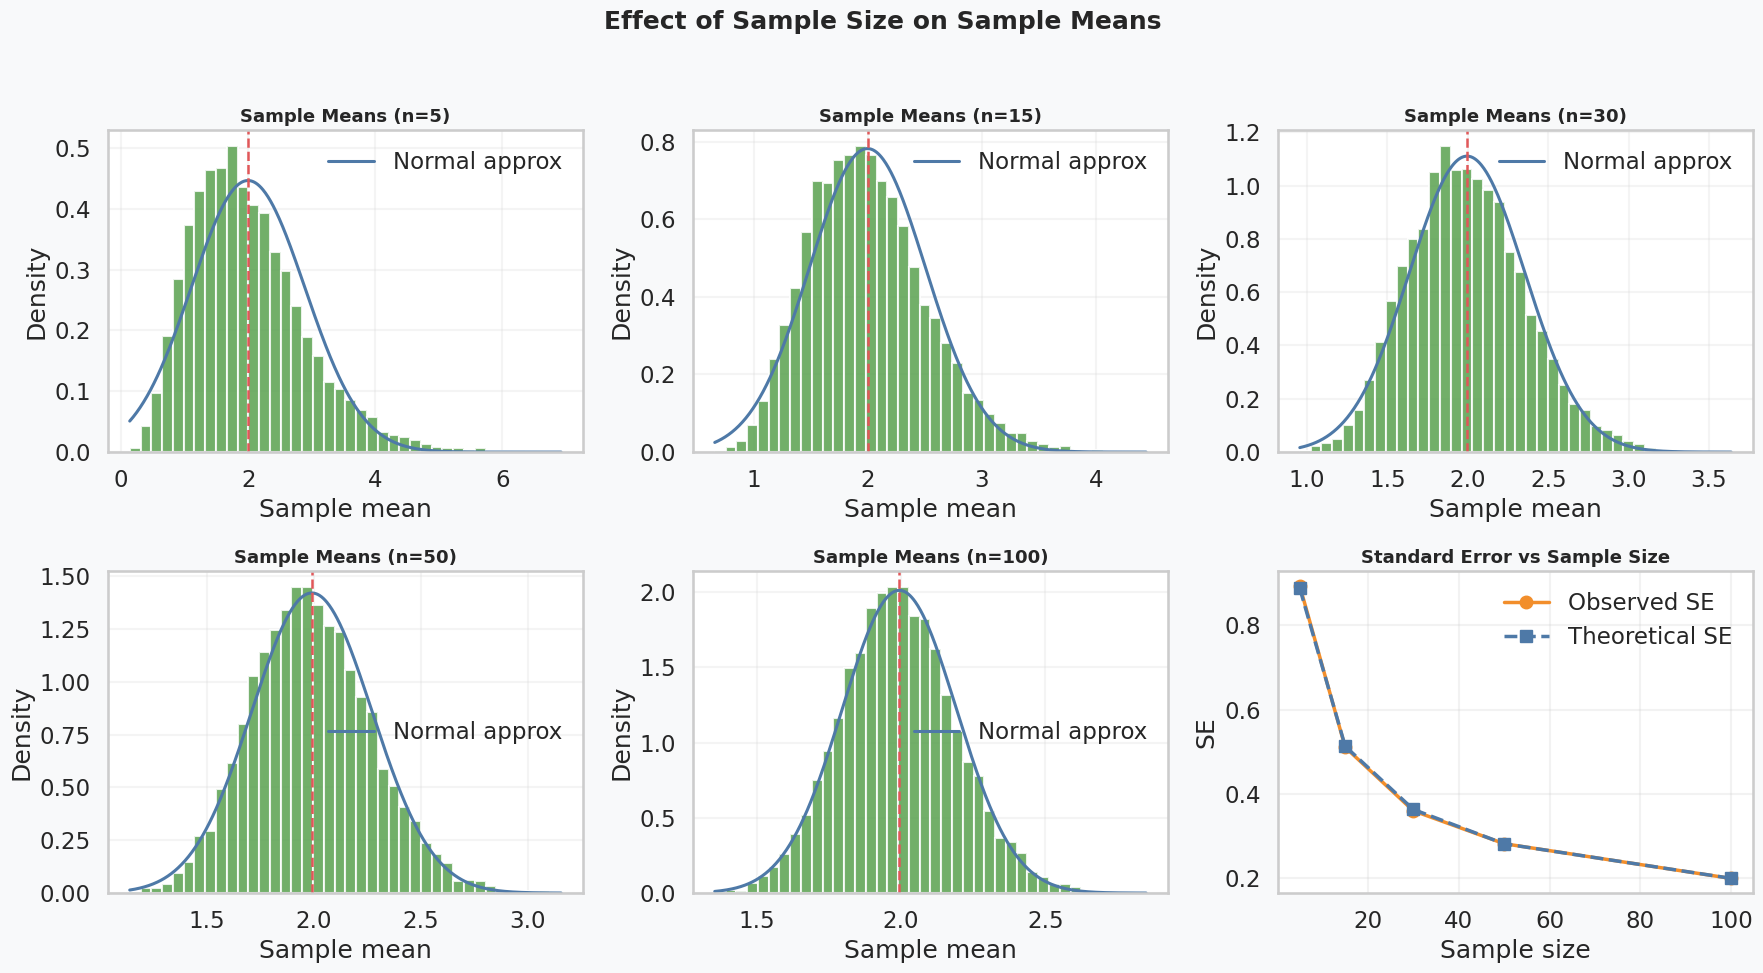

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Show how the distribution of means changes with sample size
np.random.seed(42)

sample_sizes = [5, 15, 30, 50, 100]
results_by_size = {}

for n in sample_sizes:
    sample_means_n = np.mean(
        np.random.choice(population_exp, size=(num_trials, n)),
        axis=1
    )
    results_by_size[n] = sample_means_n

# Display statistics
print("Effect of Sample Size on Standard Error:")
print("\nSample Size | Std Dev of Means | Theoretical SE | Convergence")
print("-" * 65)

observed_ses = []
theoretical_ses = []

for n in sample_sizes:
    observed_se = np.std(results_by_size[n])
    theoretical_se = population_exp_std / np.sqrt(n)
    convergence = abs(observed_se - theoretical_se) / theoretical_se * 100

    observed_ses.append(observed_se)
    theoretical_ses.append(theoretical_se)

    print(f"    {n:3d}     |      {observed_se:.4f}        |     {theoretical_se:.4f}     |  {convergence:.2f}%")

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Histograms of sample means
for i, n in enumerate(sample_sizes):
    ax = axes[i]
    sample_means_n = results_by_size[n]

    ax.hist(
        sample_means_n,
        bins=40,
        density=True,
        color="#59A14F",
        alpha=0.85,
        edgecolor="white"
    )

    mean_n = np.mean(sample_means_n)
    std_n = np.std(sample_means_n)

    x = np.linspace(sample_means_n.min(), sample_means_n.max(), 500)
    y = (1 / (std_n * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mean_n) / std_n) ** 2
    )

    ax.plot(x, y, color="#4E79A7", linewidth=2.2, label="Normal approx")
    ax.axvline(mean_n, color="#E15759", linestyle="--", linewidth=1.8)

    ax.set_title(f"Sample Means (n={n})", fontsize=13, weight="bold")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

# SE comparison plot in the last panel
ax = axes[-1]
ax.plot(sample_sizes, observed_ses, marker="o", linewidth=2.5, color="#F28E2B", label="Observed SE")
ax.plot(sample_sizes, theoretical_ses, marker="s", linewidth=2.5, color="#4E79A7", linestyle="--", label="Theoretical SE")
ax.set_title("Standard Error vs Sample Size", fontsize=13, weight="bold")
ax.set_xlabel("Sample size")
ax.set_ylabel("SE")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.suptitle("Effect of Sample Size on Sample Means", fontsize=18, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 6.Visualizations

### Visualization 1: Population vs Distribution of Sample Means (Uniform)


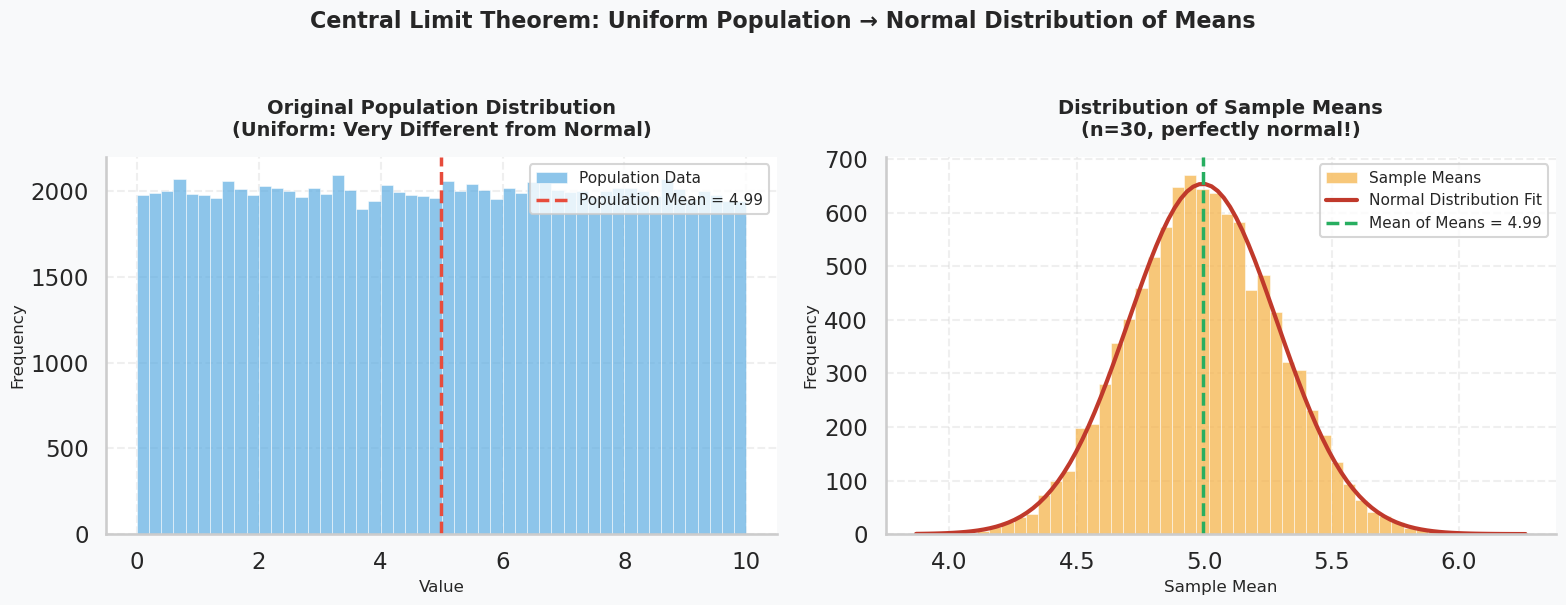


✅ Key Observation: Despite the population being uniformly distributed, the sample means follow a bell curve!


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')

# Left panel: Original population (uniform)
ax = axes[0]
ax.set_facecolor('white')
ax.hist(population, bins=50, color='#5dade2', alpha=0.7, edgecolor='white', linewidth=0.5, label='Population Data')
ax.axvline(population_mean, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Population Mean = {population_mean:.2f}')
ax.set_title('Original Population Distribution\n(Uniform: Very Different from Normal)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

# Right panel: Distribution of sample means
ax = axes[1]
ax.set_facecolor('white')
ax.hist(sample_means, bins=50, color='#f5b041', alpha=0.7, edgecolor='white', linewidth=0.5, label='Sample Means')

# Overlay normal distribution
x_range = np.linspace(sample_means.min(), sample_means.max(), 100)
normal_pdf = norm.pdf(x_range, sample_mean_mean, sample_mean_std)
# Scale to match histogram
normal_pdf_scaled = normal_pdf * (sample_means.max() - sample_means.min()) * len(sample_means) / 50
ax.plot(x_range, normal_pdf_scaled, color='#c0392b', linewidth=3, label='Normal Distribution Fit')

ax.axvline(sample_mean_mean, color='#27ae60', linestyle='--', linewidth=2.5, label=f'Mean of Means = {sample_mean_mean:.2f}')
ax.set_title(f'Distribution of Sample Means\n(n={sample_size}, perfectly normal!)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sample Mean', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.suptitle('Central Limit Theorem: Uniform Population → Normal Distribution of Means', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Key Observation: Despite the population being uniformly distributed, the sample means follow a bell curve!")

### Visualization 2: Exponential Population → Normal Distribution of Means

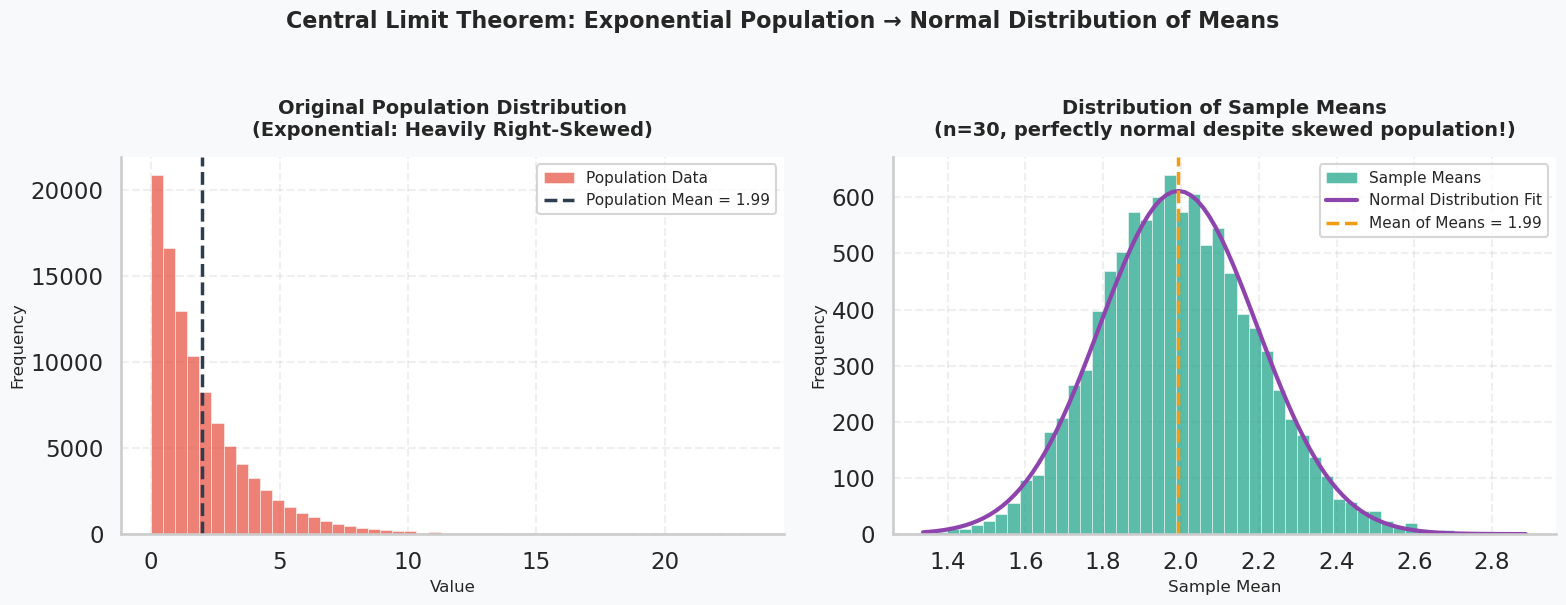


✅ Key Observation: Even an extremely skewed population produces a normal distribution of sample means!


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')

# Left panel: Original population (exponential - heavily skewed)
ax = axes[0]
ax.set_facecolor('white')
ax.hist(population_exp, bins=50, color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=0.5, label='Population Data')
ax.axvline(population_exp_mean, color='#2c3e50', linestyle='--', linewidth=2.5, label=f'Population Mean = {population_exp_mean:.2f}')
ax.set_title('Original Population Distribution\n(Exponential: Heavily Right-Skewed)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

# Right panel: Distribution of sample means
ax = axes[1]
ax.set_facecolor('white')
ax.hist(sample_means_exp, bins=50, color='#16a085', alpha=0.7, edgecolor='white', linewidth=0.5, label='Sample Means')

# Overlay normal distribution
x_range = np.linspace(sample_means_exp.min(), sample_means_exp.max(), 100)
normal_pdf = norm.pdf(x_range, np.mean(sample_means_exp), np.std(sample_means_exp))
normal_pdf_scaled = normal_pdf * (sample_means_exp.max() - sample_means_exp.min()) * len(sample_means_exp) / 50
ax.plot(x_range, normal_pdf_scaled, color='#8e44ad', linewidth=3, label='Normal Distribution Fit')

ax.axvline(np.mean(sample_means_exp), color='#f39c12', linestyle='--', linewidth=2.5, label=f'Mean of Means = {np.mean(sample_means_exp):.2f}')
ax.set_title(f'Distribution of Sample Means\n(n={sample_size}, perfectly normal despite skewed population!)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sample Mean', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.suptitle('Central Limit Theorem: Exponential Population → Normal Distribution of Means', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Key Observation: Even an extremely skewed population produces a normal distribution of sample means!")

### Visualization 3: Effect of Sample Size on Convergence

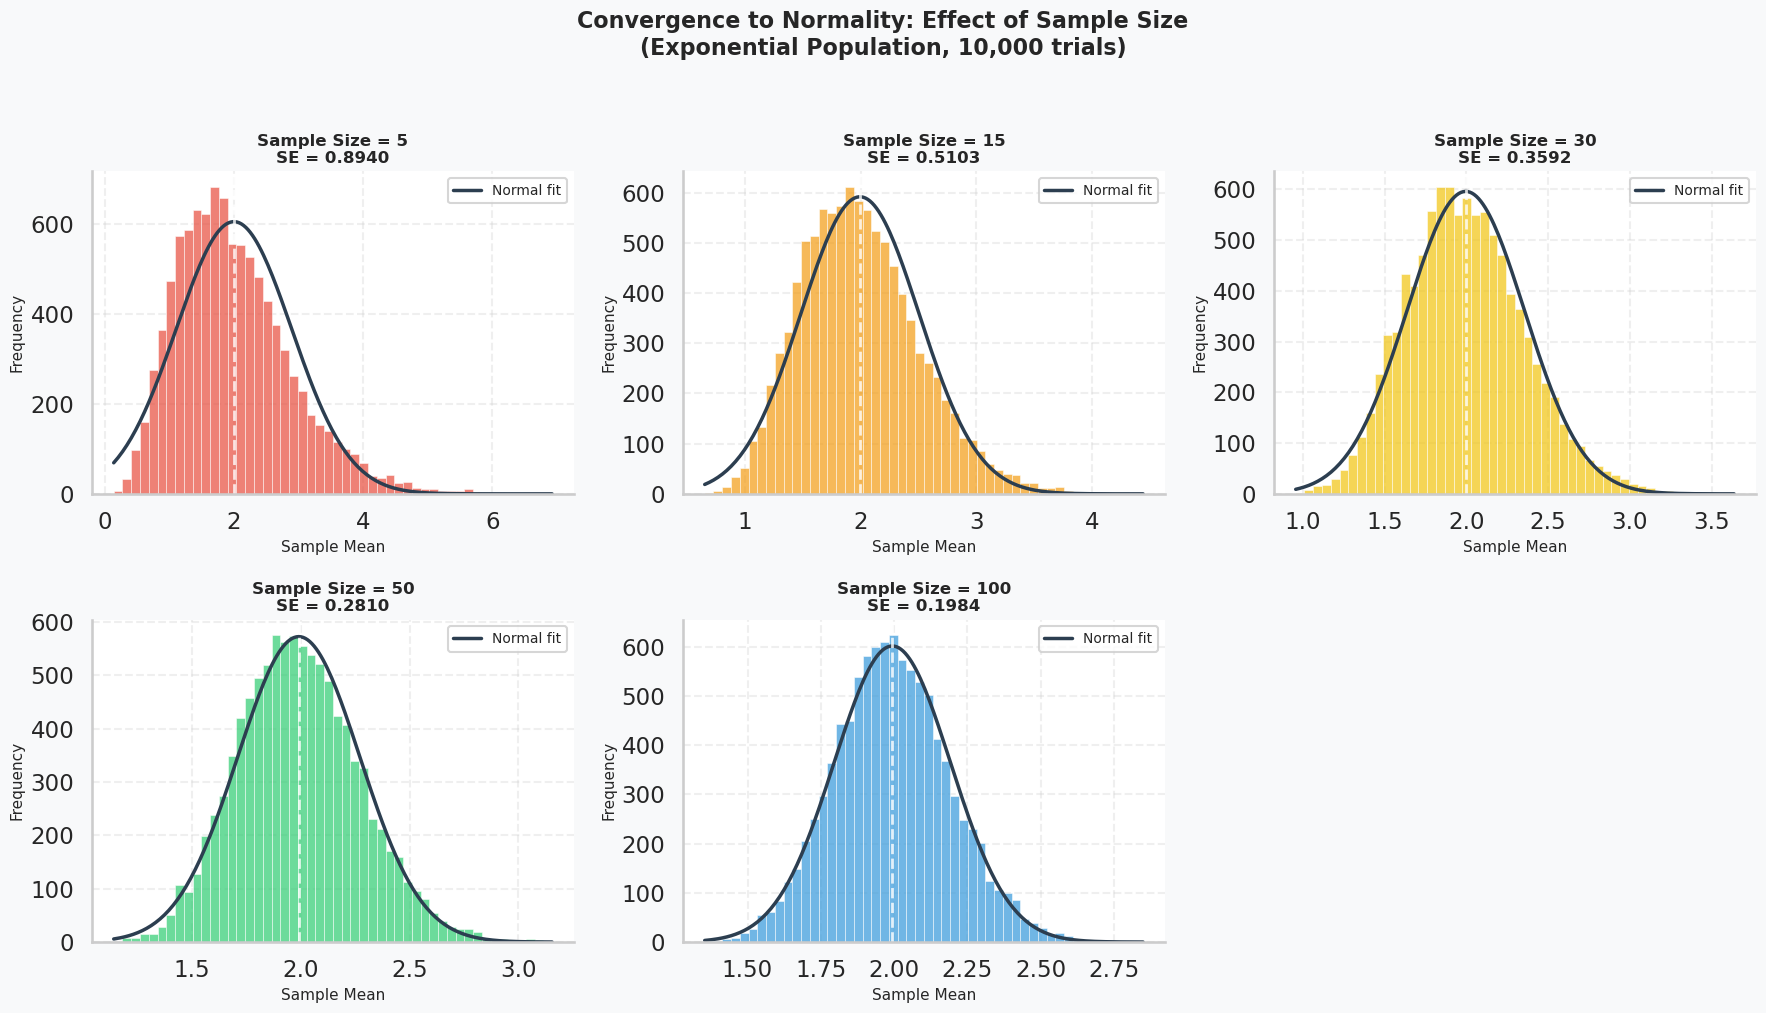

✅ Key Observation: Larger sample sizes → tighter, more normal distributions (smaller standard error)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

plot_sizes = sorted(results_by_size.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten()

colors = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']

for idx, (n, ax) in enumerate(zip(plot_sizes, axes)):
    ax.set_facecolor('white')
    data = results_by_size[n]

    ax.hist(
        data,
        bins=50,
        color=colors[idx % len(colors)],
        alpha=0.7,
        edgecolor='white',
        linewidth=0.5
    )

    x_range = np.linspace(data.min(), data.max(), 200)
    normal_pdf = norm.pdf(x_range, np.mean(data), np.std(data))
    bin_width = (data.max() - data.min()) / 50
    normal_pdf_scaled = normal_pdf * len(data) * bin_width
    ax.plot(x_range, normal_pdf_scaled, color='#2c3e50', linewidth=2.5, label='Normal fit')

    ax.axvline(np.mean(data), color='white', linestyle='--', linewidth=2, alpha=0.8)

    se = np.std(data)
    ax.set_title(f'Sample Size = {n}\nSE = {se:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Mean', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)
    sns.despine(ax=ax)

# Hide any unused subplot(s)
for ax in axes[len(plot_sizes):]:
    ax.axis('off')

plt.suptitle(
    'Convergence to Normality: Effect of Sample Size\n(Exponential Population, 10,000 trials)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

print("✅ Key Observation: Larger sample sizes → tighter, more normal distributions (smaller standard error)")

### Visualization 4: Standard Error Shrinks with Sample Size

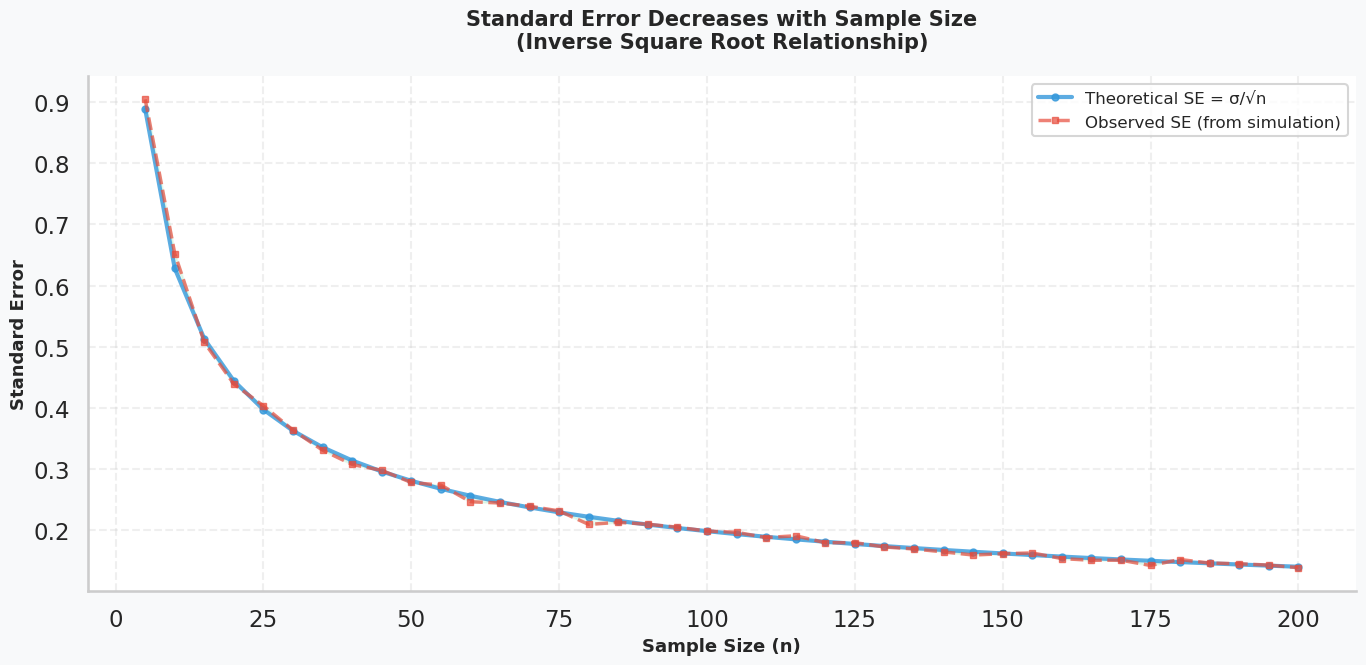


📊 Key Formula: SE = σ / √n

This means:
  • Doubling sample size reduces SE by a factor of √2 ≈ 1.41
  • To reduce SE by half, you need 4× the sample size
  • Larger samples = more precise estimates (tighter confidence intervals)


In [30]:
# Show the relationship between sample size and standard error
sample_sizes_range = np.arange(5, 201, 5)
theoretical_ses = [population_exp_std / np.sqrt(n) for n in sample_sizes_range]

# Also calculate observed SEs from our simulations
observed_ses = []
for n in sample_sizes_range:
    sample_means_n = []
    for _ in range(1000):  # Fewer trials for efficiency
        sample = np.random.choice(population_exp, size=n)
        sample_means_n.append(np.mean(sample))
    observed_ses.append(np.std(sample_means_n))

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('white')

# Plot both theoretical and observed
ax.plot(sample_sizes_range, theoretical_ses, color='#3498db', linewidth=3, label='Theoretical SE = σ/√n', marker='o', markersize=5, alpha=0.8)
ax.plot(sample_sizes_range, observed_ses, color='#e74c3c', linewidth=2.5, label='Observed SE (from simulation)', linestyle='--', marker='s', markersize=4, alpha=0.7)

# Shade the area between
ax.fill_between(sample_sizes_range, theoretical_ses, observed_ses, alpha=0.1, color='#2ecc71')

ax.set_xlabel('Sample Size (n)', fontsize=13, fontweight='bold')
ax.set_ylabel('Standard Error', fontsize=13, fontweight='bold')
ax.set_title('Standard Error Decreases with Sample Size\n(Inverse Square Root Relationship)', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print("\n📊 Key Formula: SE = σ / √n")
print("\nThis means:")
print("  • Doubling sample size reduces SE by a factor of √2 ≈ 1.41")
print("  • To reduce SE by half, you need 4× the sample size")
print("  • Larger samples = more precise estimates (tighter confidence intervals)")

### Visualization 5: Multiple Distributions → All Converge to Normal

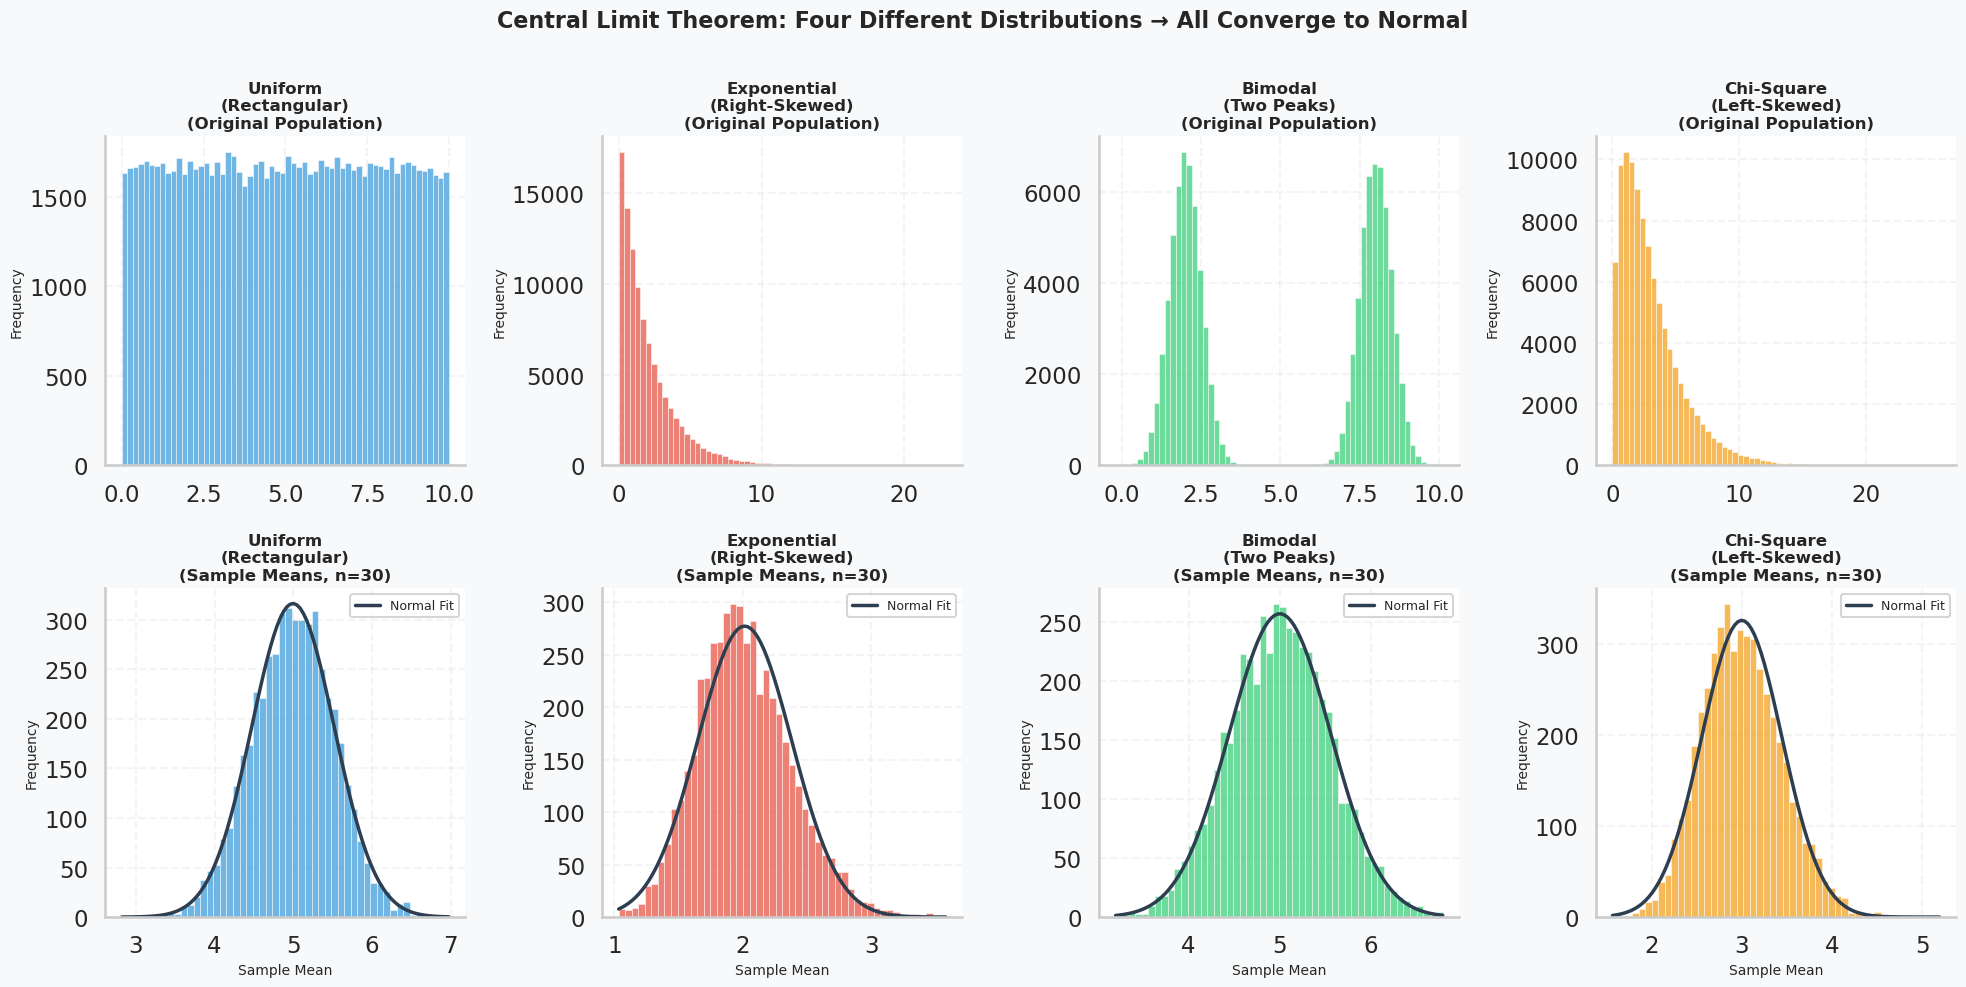


✅ Remarkable Finding: No matter how different the original distributions are,
   their sample means ALWAYS follow a normal distribution!


In [31]:
# Demonstrate CLT with 4 very different population distributions
np.random.seed(42)

# Define 4 different populations
populations_demo = {
    'Uniform\n(Rectangular)': np.random.uniform(0, 10, 100000),
    'Exponential\n(Right-Skewed)': np.random.exponential(scale=2, size=100000),
    'Bimodal\n(Two Peaks)': np.concatenate([np.random.normal(2, 0.5, 50000), np.random.normal(8, 0.5, 50000)]),
    'Chi-Square\n(Left-Skewed)': np.random.chisquare(df=3, size=100000)
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#f8f9fa')

colors_demo = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (name, pop) in enumerate(populations_demo.items()):
    # Top row: Original populations
    ax_top = axes[0, idx]
    ax_top.set_facecolor('white')
    ax_top.hist(pop, bins=60, color=colors_demo[idx], alpha=0.7, edgecolor='white', linewidth=0.5)
    ax_top.set_title(f'{name}\n(Original Population)', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('Frequency', fontsize=10)
    ax_top.grid(True, alpha=0.2, linestyle='--')
    sns.despine(ax=ax_top)
    
    # Bottom row: Distribution of sample means
    ax_bottom = axes[1, idx]
    ax_bottom.set_facecolor('white')
    
    # Generate sample means
    sample_means_demo = []
    for _ in range(5000):
        sample = np.random.choice(pop, size=30)
        sample_means_demo.append(np.mean(sample))
    sample_means_demo = np.array(sample_means_demo)
    
    ax_bottom.hist(sample_means_demo, bins=50, color=colors_demo[idx], alpha=0.7, edgecolor='white', linewidth=0.5)
    
    # Overlay normal distribution
    x_range = np.linspace(sample_means_demo.min(), sample_means_demo.max(), 100)
    normal_pdf = norm.pdf(x_range, np.mean(sample_means_demo), np.std(sample_means_demo))
    normal_pdf_scaled = normal_pdf * (sample_means_demo.max() - sample_means_demo.min()) * len(sample_means_demo) / 50
    ax_bottom.plot(x_range, normal_pdf_scaled, color='#2c3e50', linewidth=2.5, label='Normal Fit')
    
    ax_bottom.set_title(f'{name}\n(Sample Means, n=30)', fontsize=12, fontweight='bold')
    ax_bottom.set_xlabel('Sample Mean', fontsize=10)
    ax_bottom.set_ylabel('Frequency', fontsize=10)
    ax_bottom.grid(True, alpha=0.2, linestyle='--')
    ax_bottom.legend(loc='upper right', fontsize=9)
    sns.despine(ax=ax_bottom)

plt.suptitle('Central Limit Theorem: Four Different Distributions → All Converge to Normal', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✅ Remarkable Finding: No matter how different the original distributions are,")
print("   their sample means ALWAYS follow a normal distribution!")

### Visualization 6: Q-Q Plots (Normality Assessment)

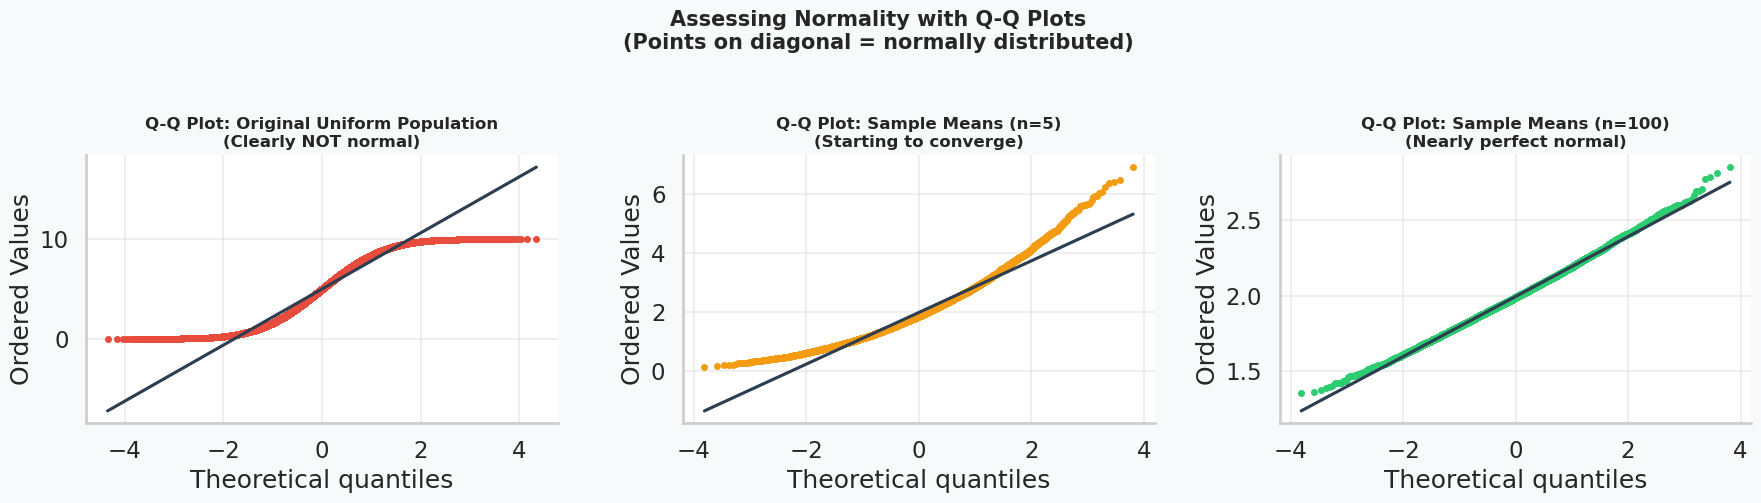


📊 How to Read Q-Q Plots:
   • Points close to the diagonal → data is normally distributed
   • Points deviate at the tails → data has heavier/lighter tails than normal
   • S-curve pattern → skewed data


In [32]:
# Q-Q plots visually assess how well data fits a normal distribution
# Points on the diagonal = normally distributed

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#f8f9fa')

# 1. Population (uniform) - NOT normal
ax = axes[0]
ax.set_facecolor('white')
stats.probplot(population, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Original Uniform Population\n(Clearly NOT normal)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.get_lines()[0].set_color('#e74c3c')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('#2c3e50')
sns.despine(ax=ax)

# 2. Small sample means (n=5) - Getting closer to normal
ax = axes[1]
ax.set_facecolor('white')
stats.probplot(results_by_size[5], dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Sample Means (n=5)\n(Starting to converge)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.get_lines()[0].set_color('#f39c12')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('#2c3e50')
sns.despine(ax=ax)

# 3. Large sample means (n=100) - Nearly perfect normal
ax = axes[2]
ax.set_facecolor('white')
stats.probplot(results_by_size[100], dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Sample Means (n=100)\n(Nearly perfect normal)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.get_lines()[0].set_color('#2ecc71')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('#2c3e50')
sns.despine(ax=ax)

plt.suptitle('Assessing Normality with Q-Q Plots\n(Points on diagonal = normally distributed)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 How to Read Q-Q Plots:")
print("   • Points close to the diagonal → data is normally distributed")
print("   • Points deviate at the tails → data has heavier/lighter tails than normal")
print("   • S-curve pattern → skewed data")

### Visualization 7: Real-World Simulation - Test Scores

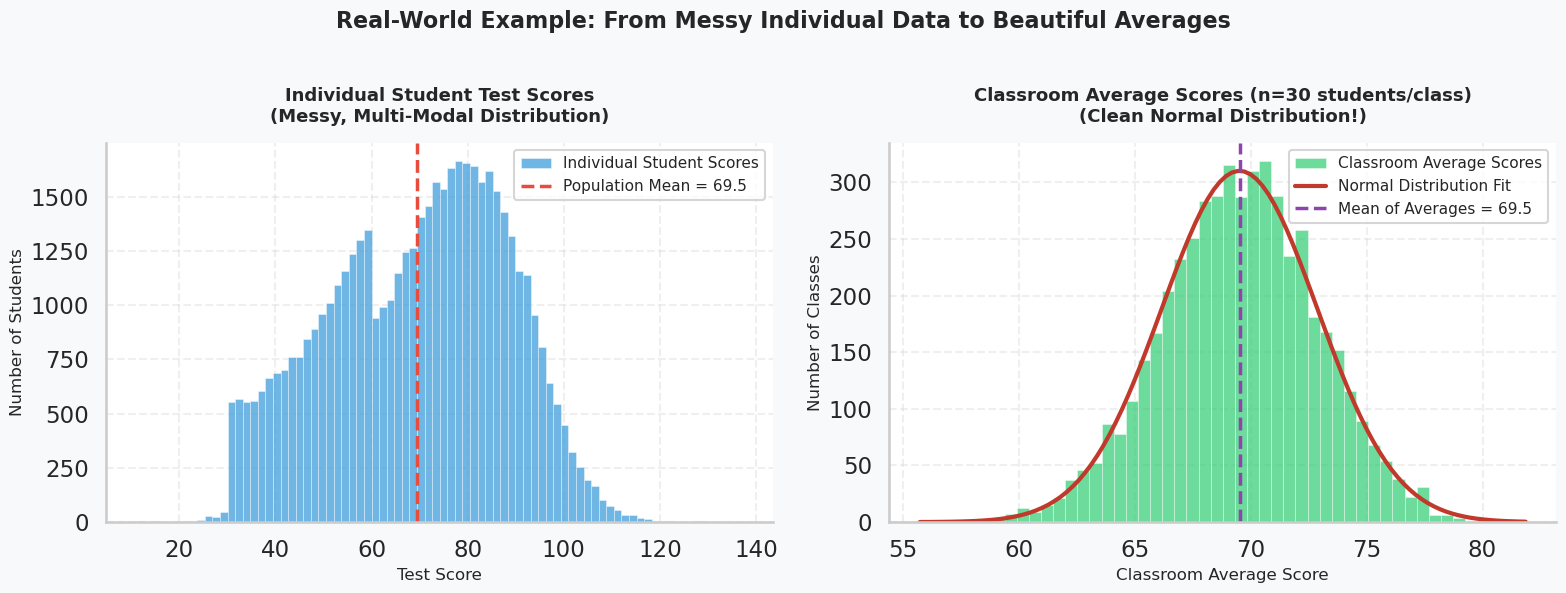


📊 Test Score Analysis:
  Individual Student Scores:
    Mean: 69.50
    Std Dev: 18.66
    Shape: Highly irregular (multi-modal)

  Classroom Averages (n=30):
    Mean: 69.51
    Std Dev: 3.36
    Theoretical SE: 3.41
    Shape: Perfectly normal


In [33]:
# Real-world example: Distribution of class average test scores
np.random.seed(42)

# Imagine a population of 50,000 students with a non-normal score distribution
# Mix of different distribution types
student_scores = np.concatenate([
    np.random.normal(70, 15, 25000),  # Main group around 70
    np.random.normal(85, 10, 15000),  # High achievers around 85
    np.random.uniform(30, 60, 10000)  # Struggling students
])

# Now imagine taking repeated classroom averages (30 students per class)
class_size = 30
num_classes = 5000
class_averages = []

for _ in range(num_classes):
    class_sample = np.random.choice(student_scores, size=class_size)
    class_averages.append(np.mean(class_sample))

class_averages = np.array(class_averages)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')

# Left: Individual student scores (messy, non-normal)
ax = axes[0]
ax.set_facecolor('white')
ax.hist(student_scores, bins=80, color='#3498db', alpha=0.7, edgecolor='white', linewidth=0.4, label='Individual Student Scores')
ax.axvline(np.mean(student_scores), color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Population Mean = {np.mean(student_scores):.1f}')
ax.set_title('Individual Student Test Scores\n(Messy, Multi-Modal Distribution)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Test Score', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

# Right: Classroom averages (clean, normal)
ax = axes[1]
ax.set_facecolor('white')
ax.hist(class_averages, bins=50, color='#2ecc71', alpha=0.7, edgecolor='white', linewidth=0.4, label='Classroom Average Scores')

# Overlay normal distribution
x_range = np.linspace(class_averages.min(), class_averages.max(), 100)
normal_pdf = norm.pdf(x_range, np.mean(class_averages), np.std(class_averages))
normal_pdf_scaled = normal_pdf * (class_averages.max() - class_averages.min()) * len(class_averages) / 50
ax.plot(x_range, normal_pdf_scaled, color='#c0392b', linewidth=3, label='Normal Distribution Fit')

ax.axvline(np.mean(class_averages), color='#8e44ad', linestyle='--', linewidth=2.5, label=f'Mean of Averages = {np.mean(class_averages):.1f}')
ax.set_title(f'Classroom Average Scores (n=30 students/class)\n(Clean Normal Distribution!)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Classroom Average Score', fontsize=12)
ax.set_ylabel('Number of Classes', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.suptitle('Real-World Example: From Messy Individual Data to Beautiful Averages', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n📊 Test Score Analysis:")
print(f"  Individual Student Scores:")
print(f"    Mean: {np.mean(student_scores):.2f}")
print(f"    Std Dev: {np.std(student_scores):.2f}")
print(f"    Shape: Highly irregular (multi-modal)")
print(f"\n  Classroom Averages (n={class_size}):")
print(f"    Mean: {np.mean(class_averages):.2f}")
print(f"    Std Dev: {np.std(class_averages):.2f}")
print(f"    Theoretical SE: {np.std(student_scores) / np.sqrt(class_size):.2f}")
print(f"    Shape: Perfectly normal")

---

## 7. Mathematical Deep Dive: Why Does the CLT Work?

The CLT works due to a combination of factors:

### 1. Averaging Reduces Variance
When you average multiple independent values, the outliers are balanced out. This reduces the total variability by a factor proportional to $\sqrt{n}$.

### 2. The Law of Large Numbers
As sample size increases, the sample mean converges to the population mean. This happens with certainty (not just probability).

### 3. Convolution of Distributions
Mathematically, summing independent random variables produces a distribution that's increasingly normal, regardless of the original distribution. This is why averaging (summing and dividing) produces normality.

### 4. Central Limit Effect
The tails of the population distribution matter less for large sample sizes. The center (mean) is stabilized by averaging.

### Key Requirements for CLT to Apply:
1. **Independence**: Samples must be drawn independently
2. **Finite variance**: The population must have a defined standard deviation (not infinite)
3. **Adequate sample size**: n should be "large enough" (typically n ≥ 30 for most distributions)
4. **Random sampling**: Each observation has an equal chance of being selected

---

## 8. Key Takeaways & Practical Implications

In [34]:
print("="*80)
print(" " * 15 + "CENTRAL LIMIT THEOREM: KEY TAKEAWAYS")
print("="*80)

takeaways = [
    {
        "title": "1. THE MAGIC OF AVERAGING",
        "key_idea": "No matter how messy the original data is, averages become normal.",
        "implication": "You can use normal distribution tools (confidence intervals, z-tests) on sample means from any population."
    },
    {
        "title": "2. STANDARD ERROR SHRINKS WITH √n",
        "key_idea": "SE = σ / √n means larger samples give tighter estimates.",
        "implication": "To halve the standard error, you need 4× the sample size. This determines required sample sizes in A/B tests and surveys."
    },
    {
        "title": "3. CONFIDENCE INTERVALS WORK BECAUSE OF CLT",
        "key_idea": "A 95% CI is built on the assumption that sample means are normally distributed.",
        "implication": "You can estimate population parameters with a known margin of error using just a sample."
    },
    {
        "title": "4. HYPOTHESIS TESTING RELIES ON CLT",
        "key_idea": "T-tests, z-tests, ANOVA all assume the sample mean is normally distributed.",
        "implication": "These tests work even on non-normal populations, as long as n ≥ 30."
    },
    {
        "title": "5. SAMPLE SIZE MATTERS MORE THAN DISTRIBUTION",
        "key_idea": "A large sample from a skewed population beats a small sample from a normal population.",
        "implication": "Don't worry if your data isn't normally distributed. If your sample is large enough, CLT saves you."
    },
    {
        "title": "6. ROBUST INFERENCE FROM MESSY DATA",
        "key_idea": "Real-world data is rarely perfect. CLT lets us draw statistical conclusions anyway.",
        "implication": "In business, medicine, and science, CLT is why we can trust results from imperfect data."
    },
]

for takeaway in takeaways:
    print(f"\n{takeaway['title']}")
    print(f"  Key Idea: {takeaway['key_idea']}")
    print(f"  Implication: {takeaway['implication']}")

print("\n" + "="*80)

               CENTRAL LIMIT THEOREM: KEY TAKEAWAYS

1. THE MAGIC OF AVERAGING
  Key Idea: No matter how messy the original data is, averages become normal.
  Implication: You can use normal distribution tools (confidence intervals, z-tests) on sample means from any population.

2. STANDARD ERROR SHRINKS WITH √n
  Key Idea: SE = σ / √n means larger samples give tighter estimates.
  Implication: To halve the standard error, you need 4× the sample size. This determines required sample sizes in A/B tests and surveys.

3. CONFIDENCE INTERVALS WORK BECAUSE OF CLT
  Key Idea: A 95% CI is built on the assumption that sample means are normally distributed.
  Implication: You can estimate population parameters with a known margin of error using just a sample.

4. HYPOTHESIS TESTING RELIES ON CLT
  Key Idea: T-tests, z-tests, ANOVA all assume the sample mean is normally distributed.
  Implication: These tests work even on non-normal populations, as long as n ≥ 30.

5. SAMPLE SIZE MATTERS MORE TH

## Practical Applications of CLT

### 1. **Quality Control in Manufacturing**
Monitor averages of production batches. Even if individual units vary wildly, their averages follow a predictable distribution. Use control charts to detect when the process shifts.

### 2. **Polling & Elections**
A poll of 1,000 voters provides a sample mean (% supporting a candidate). CLT tells us the margin of error: ~3% at 95% confidence.

### 3. **A/B Testing**
Compare average performance (conversion rate, click-through rate) between two versions. CLT ensures that the difference in averages is normally distributed, so you can calculate significance.

### 4. **Medical Trials**
Blood pressure readings vary for each patient. But the *average* blood pressure of treatment groups follows a normal distribution, enabling rigorous comparison.

### 5. **Risk Management in Finance**
Daily stock returns are noisy, but the average return over a time period is more predictable. CLT helps estimate Value at Risk (VaR).

### 6. **Pricing & Revenue Analytics**
Individual customer purchases vary wildly. But the average transaction value from day to day is stable and normally distributed, enabling revenue forecasting.

---

## 9. When CLT Fails (Important Caveats)

In [35]:
print("\n⚠️  IMPORTANT: When Does CLT NOT Apply?\n")

failures = [
    {
        "scenario": "Heavy-Tailed Distributions",
        "example": "Wealth distribution, insurance claims, market returns",
        "problem": "Extreme outliers exert disproportionate influence. CLT convergence is slow (n may need to be 1000+)",
        "fix": "Use robust methods or transform the data (e.g., log transformation)"
    },
    {
        "scenario": "Non-Independent Samples",
        "example": "Time series data, clustered observations",
        "problem": "CLT assumes independence. Autocorrelated data violates this assumption.",
        "fix": "Use specialized methods for correlated data (e.g., time series models)"
    },
    {
        "scenario": "Very Small Samples",
        "example": "n = 5 from a skewed population",
        "problem": "CLT hasn't converged yet. Sample means may still be skewed.",
        "fix": "Use t-distribution (more conservative) or increase sample size"
    },
    {
        "scenario": "Infinite Variance",
        "example": "Pareto distribution, Cauchy distribution",
        "problem": "CLT mathematically doesn't apply. The standard deviation is undefined.",
        "fix": "Use non-parametric methods or alternative theoretical approaches"
    }
]

for i, failure in enumerate(failures, 1):
    print(f"❌ {failure['scenario']}")
    print(f"   Example: {failure['example']}")
    print(f"   Problem: {failure['problem']}")
    print(f"   Solution: {failure['fix']}")
    print()


⚠️  IMPORTANT: When Does CLT NOT Apply?

❌ Heavy-Tailed Distributions
   Example: Wealth distribution, insurance claims, market returns
   Problem: Extreme outliers exert disproportionate influence. CLT convergence is slow (n may need to be 1000+)
   Solution: Use robust methods or transform the data (e.g., log transformation)

❌ Non-Independent Samples
   Example: Time series data, clustered observations
   Problem: CLT assumes independence. Autocorrelated data violates this assumption.
   Solution: Use specialized methods for correlated data (e.g., time series models)

❌ Very Small Samples
   Example: n = 5 from a skewed population
   Problem: CLT hasn't converged yet. Sample means may still be skewed.
   Solution: Use t-distribution (more conservative) or increase sample size

❌ Infinite Variance
   Example: Pareto distribution, Cauchy distribution
   Problem: CLT mathematically doesn't apply. The standard deviation is undefined.
   Solution: Use non-parametric methods or alternati

---

## 10. Final Summary

### The Central Limit Theorem in One Sentence:
> **The average of a large sample from any distribution is approximately normally distributed, with precision improving as sample size increases.**

### Why It's Revolutionary:
1. **Universality**: Works for any population distribution (uniform, exponential, bimodal, etc.)
2. **Predictability**: We know exactly how precise our estimate is (via standard error)
3. **Practicality**: Enables statistical inference, hypothesis testing, and confidence intervals
4. **Robustness**: Even when data is messy, averaging cleans it up

### What This Means for You:
- When someone reports a poll result, CLT ensures the margin of error is valid
- When a company claims A/B test significance, CLT justifies the statistical methodology
- When a doctor discusses clinical trial results, CLT provides the theoretical foundation
- When analysts forecast revenue, CLT predicts the precision of their forecasts

**The Central Limit Theorem is why statistics works. It's the bridge between messy reality and clean mathematics.**

In [36]:
# Final visualization: The power of CLT summarized
print("\n" + "="*80)
print(" " * 20 + "CENTRAL LIMIT THEOREM SUMMARY")
print("="*80)
print("""
┌─────────────────────────────────────────────────────────────────────┐
│  START: Any population (normal, skewed, bimodal, uniform, etc.)    │
└────────────────────────────┬────────────────────────────────────────┘
                             │
                             ↓
              Take a random sample of size n
              Calculate its mean: x̄
                             │
                             ↓
          Repeat this 1000+ times, collecting x̄ values
                             │
                             ↓
┌─────────────────────────────────────────────────────────────────────┐
│  RESULT: Distribution of means is ALWAYS normal!                  │
│  - Mean of means = μ (population mean)                            │
│  - Std Dev of means = σ/√n (standard error)                       │
│  - Larger n → tighter distribution → more precise estimates       │
└─────────────────────────────────────────────────────────────────────┘
                             │
                             ↓
         Use this normal distribution for inference:
         • Confidence intervals
         • Hypothesis tests
         • Risk quantification
         • Decision making under uncertainty
""")
print("="*80)


                    CENTRAL LIMIT THEOREM SUMMARY

┌─────────────────────────────────────────────────────────────────────┐
│  START: Any population (normal, skewed, bimodal, uniform, etc.)    │
└────────────────────────────┬────────────────────────────────────────┘
                             │
                             ↓
              Take a random sample of size n
              Calculate its mean: x̄
                             │
                             ↓
          Repeat this 1000+ times, collecting x̄ values
                             │
                             ↓
┌─────────────────────────────────────────────────────────────────────┐
│  RESULT: Distribution of means is ALWAYS normal!                  │
│  - Mean of means = μ (population mean)                            │
│  - Std Dev of means = σ/√n (standard error)                       │
│  - Larger n → tighter distribution → more precise estimates       │
└────────────────────────────────────────────────────────